# **Lab 6: Lakeflow Spark Declarative Pipelines**

Lecturer: `Sirasit Lochanachit`


Course: `06026213 Big Data Systems`

Term: `02/2025`

Lab materials prepared by `Sasithorn (TA) - 2025`

# Example 1: Simple ETL pipeline with Lakeflow Spark Declarative Pipelines

ในตัวอย่างนี้จะแสดงการสร้างและ deploy ETL (extract, transform, load) pipeline สำหรับ data orchestration โดยใช้ Lakeflow Spark Declarative Pipelines และ Auto Loader
- ETL Pipeline คือการทำขั้นตอนการอ่านข้อมูลจาก source systems แล้วทำการ transform ข้อมูลตาม requirement เช่น การทำ data quality checks และการลบข้อมูลซ้ำ จากนั้นทำการเขียนข้อมูลลงบน target system เช่น data warehouse หรือ data lake

ดังนั้นตัวอย่างนี้จะสาธิตการใช้ pipeline และ Auto Loader ในการ
- ingest raw source data
- transform raw source data และ write transformed data ไปเป็น 3 materialized views
- query the transformed data
- automate the ETL pipeline with a Databricks Job

## About the dataset

Dataset ที่เราใช้จะเป็น subset ของ [Million Song Dataset](http://millionsongdataset.com/) ซึ่งเป็น collection ของ features และ metadata ของ contemporary music tracks 
- Dataset นี้มีอยู่ใน sample datasets บน Databricks workspace

# Step 1: Create a pipeline

1. ในหน้าหลัก คลิกปุ่ม `+ New` ที่ sidebar → `ETL Pipeline`

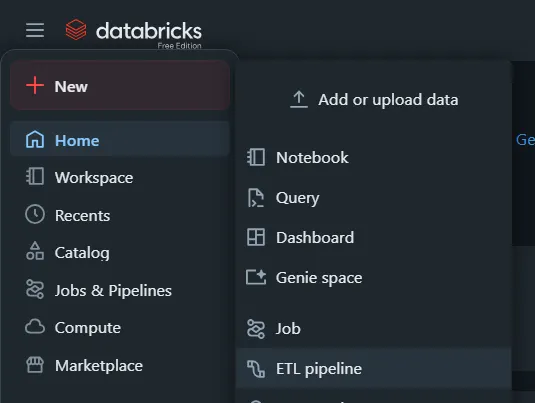

2. ตั้งชื่อ Pipeline
3. ใน Dropdown ให้เลือก catalog กับ schema สำหรับ data ที่จะ generate
    - เฉพาะตัวอย่างนี้สามารถใช้ workspace.default ได้

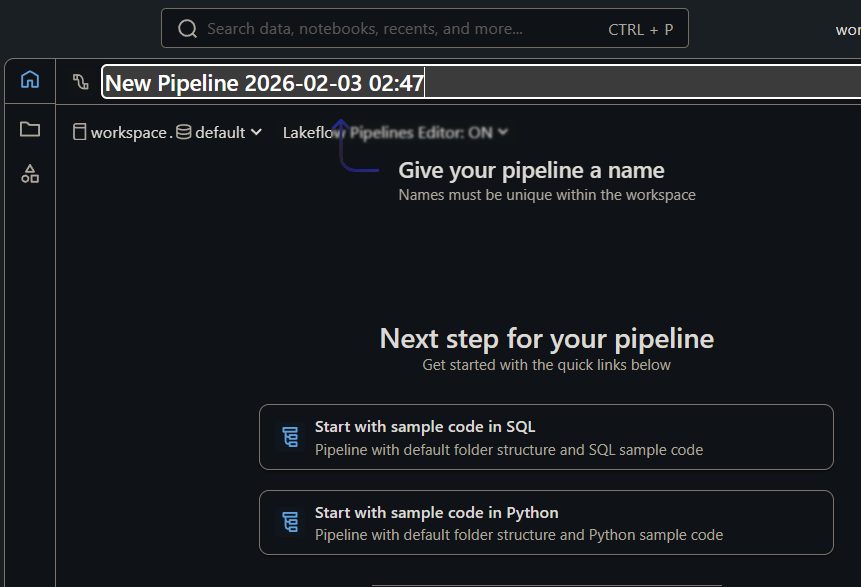

4. ตรง advanced options ให้คลิก Start with an empty file
5. ในหน้า Select a folder for your code ในช่อง folder path ด้านซ้าย ให้เลือก location สำหรับ pipeline folder หรือสามารถใช้ค่า default (folder ชื่อเรา)
6. เลือก Python หรือ SQL สำหรับ source file อันแรกของเราได้เลย ในที่นี้เราใช้ Python
    - pipeline สามารถใช้ได้หลายภาษา แต่ว่าในแต่ละไฟล์จะต้องเป็นภาษาเดียวเท่านั้น
7. คลิกปุ่ม Select

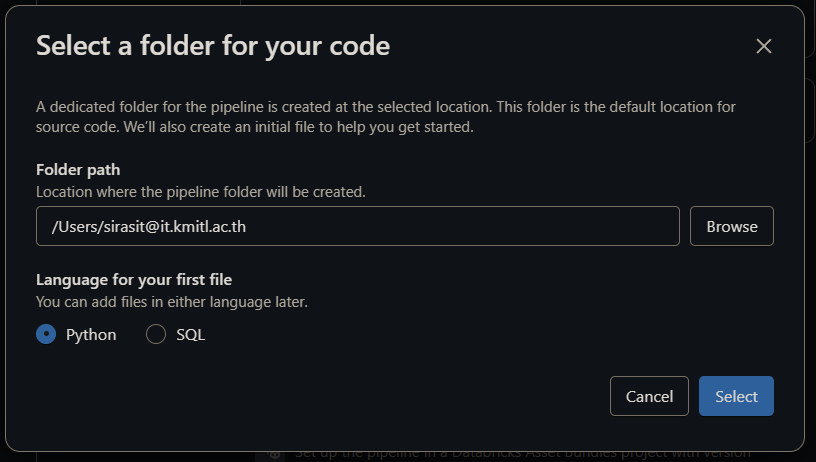

# Step 2: Develop your pipeline logic

ในขั้นตอนนี้เราจะใช้ lakeflow pipeline editor (ซึ่งก็คือในหน้า pipeline ที่เราเข้ามา) ในการ develop และ validate source code สำหรับ pipeline

Code ตัวอย่างด้านล่างจะใช้ Auto Loader สำหรับ incremental data ingestion ซึ่งก็คือการ detect และ process new file โดยอัตโนมัติเมื่อมี file ใหม่เข้ามาใน cloud object storage

ตอนที่สร้าง pipeline ครั้งแรกจะมี source code file เปล่าถูกสร้างขึ้นมา ซึ่งไฟล์นี้อยู่ใน transformation folder ของ pipeline
- โดยทั่วไป ไฟล์ประเภท .py และ .sql จะอยู่ใน transformation folder

1. Copy and paste code ด้านล่างนี้ไปยัง source file ของเรา (my_transformation.py)

In [ ]:
# Import modules
from pyspark import pipelines as dp
from pyspark.sql.functions import *
from pyspark.sql.types import DoubleType, IntegerType, StringType, StructType, StructField

# Define the path to the source data
file_path = f"/databricks-datasets/songs/data-001/"

# Define a streaming table to ingest data from a volume
schema = StructType(
  [
    StructField("artist_id", StringType(), True),
    StructField("artist_lat", DoubleType(), True),
    StructField("artist_long", DoubleType(), True),
    StructField("artist_location", StringType(), True),
    StructField("artist_name", StringType(), True),
    StructField("duration", DoubleType(), True),
    StructField("end_of_fade_in", DoubleType(), True),
    StructField("key", IntegerType(), True),
    StructField("key_confidence", DoubleType(), True),
    StructField("loudness", DoubleType(), True),
    StructField("release", StringType(), True),
    StructField("song_hotnes", DoubleType(), True),
    StructField("song_id", StringType(), True),
    StructField("start_of_fade_out", DoubleType(), True),
    StructField("tempo", DoubleType(), True),
    StructField("time_signature", DoubleType(), True),
    StructField("time_signature_confidence", DoubleType(), True),
    StructField("title", StringType(), True),
    StructField("year", IntegerType(), True),
    StructField("partial_sequence", IntegerType(), True)
  ]
)

@dp.materialized_view(
  comment="Raw data from a subset of the Million Song Dataset; a collection of features and metadata for contemporary music tracks."
)
def songs_raw():
  return (spark.read
    .format("csv")
    .schema(schema)
    .option("sep","\t")
    .load(file_path))

# Define a materialized view that validates data and renames a column
@dp.materialized_view(
  comment="Million Song Dataset with data cleaned and prepared for analysis."
)
@dp.expect("valid_artist_name", "artist_name IS NOT NULL")
@dp.expect("valid_title", "song_title IS NOT NULL")
@dp.expect("valid_duration", "duration > 0")
def songs_prepared():
  return (
    spark.read.table("songs_raw")
      .withColumnRenamed("title", "song_title")
      .select("artist_id", "artist_name", "duration", "release", "tempo", "time_signature", "song_title", "year")
  )

# Define a materialized view that has a filtered, aggregated, and sorted view of the data
@dp.materialized_view(
  comment="A table summarizing counts of songs released by the artists who released the most songs each year."
)
def top_artists_by_year():
  return (
    spark.read.table("songs_prepared")
      .filter(expr("year > 0"))
      .groupBy("artist_name", "year")
      .count().withColumnRenamed("count", "total_number_of_songs")
      .sort(desc("total_number_of_songs"), desc("year"))
  )

Code นี้ประกอบด้วย 3 function หรือ 3 query ซึ่งสามารถแยกเก็บเป็นไฟล์แยกได้

2. คลิก `Run file` หรือ `Run pipeline` เพื่อเริ่มการ update สำหรับ pipeline ที่เชื่อมอยู่
- เมื่อการ update เสร็จสิ้น ตัว editor จะมีการ update ข้อมูลเกี่ยวกับ pipeline
- Pipeline graph (DAG) ใน sidebar ด้านขวา แสดงตาราง 3 ตารางคือ `songs_raw`, `songs_prepared`, และ `top_artists_by_year`
- รายละเอียดของตารางที่สร้างขึ้นมาจะแสดงอยู่ในหน้าต่างด้านล่าง

# Step 3: Explore the datasets created by your pipeline

ในขั้นตอนนี้จะทำการส่ง ad-hoc query บนข้อมูลที่ถูก process แล้วใน ETL pipeline เพื่อวิเคราะห์ข้อมูลเพลงใน Databricks SQL Editor โดย query เหล่านี้จะใช้ข้อมูล records ที่พึ่งถูกสร้างมาในขั้นตอนที่แล้ว

## 1. Run query ที่ค้นหา artists ที่ release เพลงมากที่สุดในแต่ละปีโดยเริ่มตั้งแต่ปี 1990

1. ใน pipeline assets browser ตรงแถบด้านซ้าย ที่มี folder pipeline ของเรา ให้คลิก + จากนั้นคลิก `Exploration`
2. ตั้งชื่อ แล้วเลือก notebook ให้เป็น SQL, พอเราสร้างไฟล์มาแล้ว ไฟล์ที่สร้างใน explorations folder จะไม่ถูก run เป็นส่วนหนึ่งของ pipeline โดย default

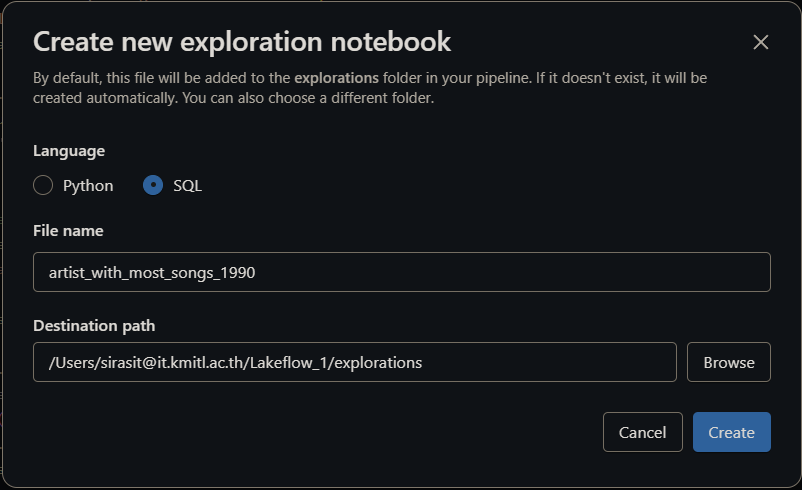

3. Copy code ข้างล่างนี้ไปยัง file SQL Notebook ที่พึ่งสร้างขึ้นมา
    - อย่าลืมปรับ path ให้ถูกต้องตามที่เรามี

In [ ]:
-- Which artists released the most songs each year in 1990 or later?
SELECT artist_name, total_number_of_songs, year
  -- replace with the catalog/schema you are using:
  FROM workspace.default.top_artists_by_year
  WHERE year >= 1990
  ORDER BY total_number_of_songs DESC, year DESC;

4. คลิกปุ่ม  หรือกด Shift + Enter เพื่อ run query

## 2. Run query ที่ค้นหาเพลงที่มี 4/4 beat และ tempo ระหว่าง 100 และ 140

Copy และเพิ่ม code ข้างล่างนี้ไปยัง file SQL

In [ ]:
-- Find songs with a 4/4 beat and danceable tempo
SELECT artist_name, song_title, tempo
  -- replace with the catalog/schema you are using:
  FROM workspace.default.songs_prepared
  WHERE time_signature = 4 AND tempo between 100 and 140;

กด Shift + Enter เพื่อ run query

# Step 4: Create a job to run the pipeline

สร้าง workflow ที่ automate ทั้ง data ingestion, processing, analysis ไปตาม step โดยใช้ Databricks job ซึ่งจะรันตามตารางเวลาที่เรากำหนดไว้

1. บนสุดของ editor จะมีปุ่ม `Schedule`
2. หากมี `Schedule` dialog โผล่ขึ้นมาให้เลือก `Add Schedule` หากไม่มีจะเป็น `New Schedule` dialog ที่โผล่ขึ้นมา
3. เลือก job ที่ต้องการ run pipeline ตาม schedule
4. ตั้งชื่อ schedule
5. โดย default นั้น schedule จะถูกตั้งไว้ให้ run 1 ครั้งต่อวัน ซึ่งเราสามารถกำหนดเองได้ โดยไปที่ `Advanced`
6. เลือกปุ่ม Create เพื่อสร้าง job ขึ้นมา

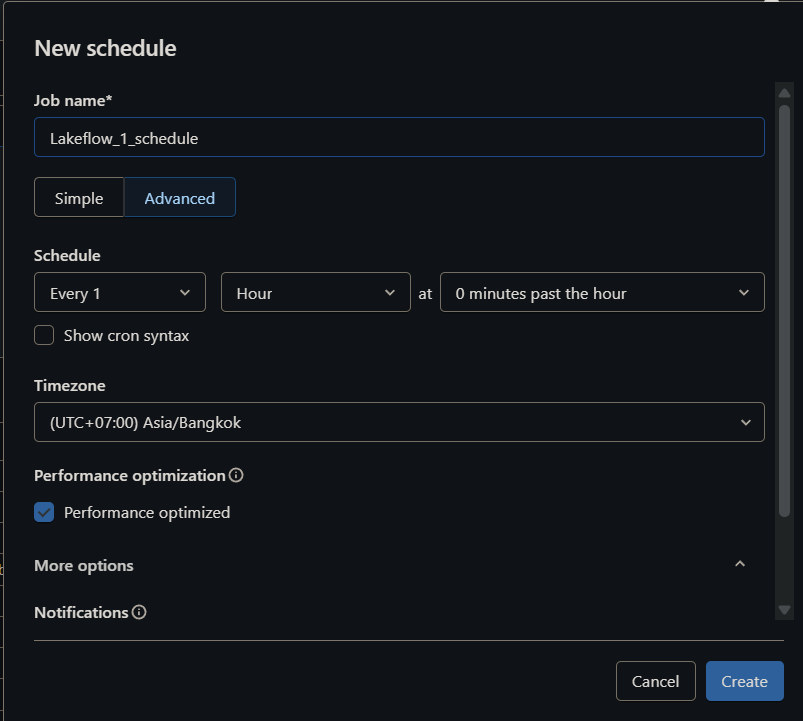

ณ ตอนนี้ job ก็จะทำการ run ตามเวลาที่กำหนดเพื่อให้ pipeline มีข้อมูลที่ update ให้เป็นปัจจุบัน

---

# Example 2: ETL pipeline using change data capture (CDC)

ในตัวอย่างนี้จะใช้ data จาก `customers` table ใน MySQL database เพื่อทำการ
- Extract change จาก transactional database แล้วบันทึกลง cloud object storage 
    - ในตัวอย่างนี้เราจะไม่ setup external CDC system แต่จะใช้การ generate fake data แทน
- ใช้ Auto Loader ในการ load messages จาก cloud object storate แบบ incremental และเก็บ raw message ใน `customers_cdc` table
- สร้าง `customers_cdc_clean` table เพื่อ check data quality เช่น `id` ไม่ควรมีค่า null
- run `AUTO CDC ... INTO` บน CDC data ที่ clean แล้วเพื่อ upsert change ไปยัง final `customers` table

เป้าหมายคือการ ingest raw data แบบใกล้เคียง real time และสร้าง table สำหรับทีม analyst ในขณะที่ data quality ยังคงมีอยู่

Architecture ของตัวอย่างนี้จะใช้ medallion Lakehouse ซึ่งเริ่มจากการ ingest raw data ใน bronze layer, จากนั้น clean และ validate data ใน silver layer และท้ายสุดทำ modeling และ aggregation ใน gold layer

![Implement_flow](https://docs.databricks.com/aws/en/assets/images/dlt_tutorial_cdc_pipeline-67c71b9b87b8463d77a9ef709725a575.png)

[อะไรคือ CDC](https://docs.databricks.com/aws/en/ldp/what-is-change-data-capture) Document

## CDC in an ETL pipeline

CDC คือกระบวนการหนึ่งที่บันทึกการเปลี่ยนแปลงของ record ที่เกิดขึ้นใน transactional database (เช่น MySQL, PostgreSQL) หรือ data warehouse โดย CDC จะตรวจจับพวกการดำเนินการต่างๆเช่น การลบ การเพิ่ม หรือการ update ข้อมูล โดยทั่วไปจะแสดงออกมาเป็น Stream เพื่อสร้างเป็นตารางใหม่ในปลายทาง และนอกจากนี้ cdc ยังช่วยให้สามารถ load ข้อมูลแบบ incremental ได้

## Capturing CDC

ในตัวอย่างนี้ นี้เราจะใช้ข้อมูล CDC จากภายนอกอย่าง Debezium (or DMS) โดย Debezium จะจับทุกแถวที่มีการเปลี่ยนแปลง และส่งประวัติการเปลี่ยนแปลงไปยัง Kafka topics หรือเซฟเป็นไฟล์

ในที่นี้เราจะทำการดึงข้อมูล CDC จากตารางที่ชื่อ customers → ตรวจว่าข้อมูลครบถ้วนถูกต้องมั้ย → แล้วสร้างตาราง customers ขึ้นใน Lakehouse

## CDC input from Debezium

ในทุกครั้งที่เปลี่ยนแปลง เราจะได้รับข้อมูล JSON ที่มี field ทั้งหมดของแถวที่ update (id, firstename, lastname, email, address) โดยข้อความจะมี metadata เพิ่มเติมคือ

- operation : operation code ต่างๆ (`DELETE`, `APPEND`, `UPDATE)`
- operation_date : วันและเวลาที่ลงสำหรับ record ในแต่ละ operaion

ตัว Tools ตัวนี้สามารถสร้าง output อื่น ๆ ได้อีก เช่น ข้อมูลในแถวก่อนที่จะเปลี่ยนแปลง

# Step 1: Create a pipeline

1. ทำเหมือนข้อ 1-7 ในตัวอย่างที่ 1 แต่ตั้งชื่อ pipeline ว่า `Pipelines with CDC tutorial`

# Step 2: Create the sample data to import

1. ใน pipeline assets browser ตรงแถบด้านซ้าย ที่มี folder pipeline ของเรา ให้คลิก + จากนั้นคลิก `Exploration`
2. ตั้งชื่อ `CDC Setup Data` แล้วเลือก notebook ให้เป็น Python, พอเราสร้างไฟล์มาแล้ว ไฟล์ที่สร้างใน explorations folder จะไม่ถูก run เป็นส่วนหนึ่งของ pipeline โดย default
3. คลิก Create

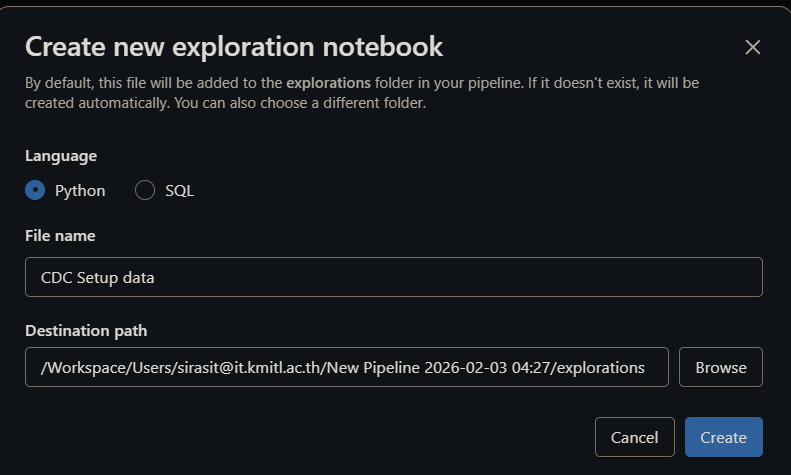

4. Copy code ด้านล่างใส่ลงใน Notebook จากนั้น run code
- อย่าลืมกำหนด catalog และ schema ให้ถูกต้อง

In [ ]:
%pip install faker
# Update these to match the catalog and schema
# that you used for the pipeline in step 1.

In [ ]:
catalog = "workspace"
schema = dbName = db = "default"

spark.sql(f'USE CATALOG `{catalog}`')
spark.sql(f'USE SCHEMA `{schema}`')
spark.sql(f'CREATE VOLUME IF NOT EXISTS `{catalog}`.`{db}`.`cdc_raw_data`')
volume_folder =  f"/Volumes/{catalog}/{db}/cdc_raw_data"

try:
  dbutils.fs.ls(volume_folder+"/customers")
except:
  print(f"folder doesn't exist, generating the data under {volume_folder}...")
  from pyspark.sql import functions as F
  from faker import Faker
  from collections import OrderedDict
  import uuid
  fake = Faker()
  import random

  fake_firstname = F.udf(fake.first_name)
  fake_lastname = F.udf(fake.last_name)
  fake_email = F.udf(fake.ascii_company_email)
  fake_date = F.udf(lambda:fake.date_time_this_month().strftime("%m-%d-%Y %H:%M:%S"))
  fake_address = F.udf(fake.address)
  operations = OrderedDict([("APPEND", 0.5),("DELETE", 0.1),("UPDATE", 0.3),(None, 0.01)])
  fake_operation = F.udf(lambda:fake.random_elements(elements=operations, length=1)[0])
  fake_id = F.udf(lambda: str(uuid.uuid4()) if random.uniform(0, 1) < 0.98 else None)

  df = spark.range(0, 100000).repartition(100)
  df = df.withColumn("id", fake_id())
  df = df.withColumn("firstname", fake_firstname())
  df = df.withColumn("lastname", fake_lastname())
  df = df.withColumn("email", fake_email())
  df = df.withColumn("address", fake_address())
  df = df.withColumn("operation", fake_operation())
  df_customers = df.withColumn("operation_date", fake_date())
  df_customers.repartition(100).write.format("json").mode("overwrite").save(volume_folder+"/customers")
     

5. หากต้องการดูข้อมูล ให้ใส่ code ด้านล่างนี้ลงไปใน notebook

In [ ]:
catalog = "workspace"
schema = "default"

display(spark.read.json(f"/Volumes/{catalog}/{schema}/cdc_raw_data/customers"))

# Step 3: Incrementally ingest data with Auto Loader

ขั้นตอนนี้เป็นการ ingest raw data จาก (faked) cloud storage เข้ามาในส่วนของ bronze layer

ความท้าทายในการ ingest raw data แบบ incremental คือ
- ต้อง operate แบบ scale ได้ ก็คือสามารถ ingest ไฟล์ขนาดเล็กๆเป็นจำนวนล้านๆไฟล์ได้
- Infer schema และ JSON type ได้
- Handle ข้อมูลที่ไม่ถูกต้องตาม JSON schema
- รองรับ schema evolution เช่น มี column ใหม่เพิ่มเข้ามา

การใช้ Auto Loader จะช่วยกระบวนการ ingestion ได้

1. ในการที่จะ ingest CDC data ที่ไหลเข้ามาโดยใช้ Auto Loader ให้ copy code ด้านล่างไปวางไว้ในไฟล์ของ pipeline (my_transformation.py)

In [ ]:
from pyspark import pipelines as dp
from pyspark.sql.functions import *

# Replace with the catalog and schema name that
# you are using:
path = "/Volumes/workspace/default/cdc_raw_data/customers"


# Create the target bronze table
dp.create_streaming_table("customers_cdc_bronze", comment="New customer data incrementally ingested from cloud object storage landing zone")

# Create an Append Flow to ingest the raw data into the bronze table
@dp.append_flow(
  target = "customers_cdc_bronze",
  name = "customers_bronze_ingest_flow"
)
def customers_bronze_ingest_flow():
  return (
      spark.readStream
          .format("cloudFiles")
          .option("cloudFiles.format", "json")
          .option("cloudFiles.inferColumnTypes", "true")
          .load(f"{path}")
  )

2. กด Shift + Enter เพื่อ run query
- เสร็จสิ้นการทำ bronze layer data ซึ่งในขั้นตอนตอ่ไปจะเป็นการ clean data เพื่อสร้าง silver layer table

# Step 4: Cleanup and expectations to track data quality

เงื่อนไขที่ต้องการเพิ่มเติม (expectation) เพื่อ control data quality:
- `ID` ต้องไม่มีค่า null
- CDC operation type ต้องถูกต้อง
- JSON ต้องอ่านได้ถูกต้องโดยใข้ Auto Loader

หากมีแถวข้อมูลที่ไม่เข้าเงื่อนไขให้ทำการ drop ทิ้ง

1. บนแถบ pipeline assets browser sidebar ให้เลือกปุ่ม `+ Add` จากนั้นเลือก `Transformation`
2. ตั้งชื่อไฟล์ python ชื่อว่า exp_clean.py และแปะ code ด้านล่างีน้

In [ ]:
from pyspark import pipelines as dp
from pyspark.sql.functions import *

dp.create_streaming_table(
  name = "customers_cdc_clean",
  expect_all_or_drop = {"no_rescued_data": "_rescued_data IS NULL","valid_id": "id IS NOT NULL","valid_operation": "operation IN ('APPEND', 'DELETE', 'UPDATE')"}
  )

@dp.append_flow(
  target = "customers_cdc_clean",
  name = "customers_cdc_clean_flow"
)
def customers_cdc_clean_flow():
  return (
      spark.readStream.table("customers_cdc_bronze")
          .select("address", "email", "id", "firstname", "lastname", "operation", "operation_date", "_rescued_data")
  )

3. กด Shift + Enter เพื่อ run query
- จะสังเกตเห็นตารางเพิ่มมาจากเดิมอีก 1 ตาราง รวมถึงใน DAG จะเห็นขั้นตอนเพิ่มมาอีก 1 ขั้น

Note: หากคลิก run pipeline จะ run pipeline นี้ตั้งแต่ต้น ถ้ามีข้อมูลที่เปลี่ยนแปลงไป มันจะดึงข้อมูลนั้นเข้ามาตั้งแต่ bronze layer เลย
- การ run ทั้ง pipeline จะไม่ไปยุ่งกับ code ในส่วนของ explorations folder เพราะไม่ได้ใช้ใน pipeline

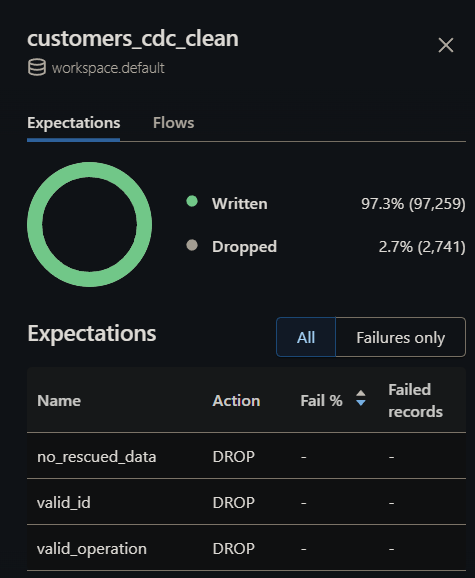

# Step 5: Materialize the customers table with an AUTO CDC flow

ในขั้นตอนก่อนหน้านี้ ตารางต่าง ๆ เพียงแค่ส่งต่อ CDC data ในแต่ละขั้นตอน แต่ว่าในขั้นตอนนี้เราจะสร้าง customers table ที่มีทั้ง up-to-date view และ replica ของ original table
ซึ่งการทำด้วยตัวเองก็ไม่ง่าย เนื่องจากต้องคำนึงในเรื่องของการลบแถวที่ซ้ำซ้อนออกเพื่อเก็บตัวที่เป็นตัวล่าสุดไว้
- LDP จึงมีตัวช่วยจัดการเรื่องนี้โดยใช้ AUTO CDC Operation

1. บนแถบ pipeline assets browser sidebar ให้เลือกปุ่ม `+ Add` จากนั้นเลือก `Transformation`
2. ตั้งชื่อไฟล์ python ชื่อว่า cdcauto.py และแปะ code ด้านล่างีน้

In [ ]:
from pyspark import pipelines as dp
from pyspark.sql.functions import *

dp.create_streaming_table(name="customers", comment="Clean, materialized customers")

dp.create_auto_cdc_flow(
  target="customers",  # The customer table being materialized
  source="customers_cdc_clean",  # the incoming CDC
  keys=["id"],  # what we'll be using to match the rows to upsert
  sequence_by=col("operation_date"),  # de-duplicate by operation date, getting the most recent value
  ignore_null_updates=False,
  apply_as_deletes=expr("operation = 'DELETE'"),  # DELETE condition
  except_column_list=["operation", "operation_date", "_rescued_data"],
)

3. กด Shift + Enter เพื่อ run query
- จะเห็นว่า pipeline graph แสดง 3 tables ซึ่งขยับจาก bronze ไปเป็น silver และไปเป็น gold

# Step 6: Track update history with slowly changing dimension type 2 (SCD2)

บ่อยครั้งที่เรามักจะสร้างตารางที่เก็บทุกการเปลี่ยนแปลงทั้งหมดจาก operation APPEND, UPDATE, DELETE

SCD2 with LDP

Delta table รองรับ CDF (Change Data Flow) และพวกการเปลี่ยนแปลงของตารางสามารถที่จะ query ดูได้ผ่าน SQL/Python แต่ทั้งนี้ทั้งนั้น CDF ใช้เพื่อ capture การเปลี่ยนแปลงของ pipeline ไม่ใช่เพื่อเก็บข้อมูลการเปลี่ยนแปลงของตารางทั้งหลายตั้งแต่เริ่ม และมันก็จะซับซ้อนขึ้นไปอีก ถ้ามี out-of-order events 
- นั่นก็คือหากเราต้องจัดลำดับการเปลี่ยนแปลงโดยอิงตาม timestamp ที่เกิดขึ้น แล้วการแก้ไขเก่าในอดีตมันถูกเพิ่มเข้ามาทีหลัง ก็จะต้องเพิ่มมันเข้าตารางและปรับข้อมูลก่อนหน้าให้เรียบร้อย

LDP จะมาช่วยลดความยากความซับซ้อนพวกนี้ และช่วยให้เราสร้างตารางแยกอันใหม่มาต่างหากที่จะเก็บการแก้ไขเปลี่ยนแปลงทั้งหลายตั้งแต่แรก ซึ่งมันจะ scale ได้ดี และจัดการพวก out-of-order event ให้ด้วย

1. คลิก + → Transformation → ตั้งชื่อ scd2.py → แปะโค้ด → run file

In [ ]:
from pyspark import pipelines as dp
from pyspark.sql.functions import *

# create the table
dp.create_streaming_table(
    name="customers_history", comment="Slowly Changing Dimension Type 2 for customers"
)

# store all changes as SCD2
dp.create_auto_cdc_flow(
    target="customers_history",
    source="customers_cdc_clean",
    keys=["id"],
    sequence_by=col("operation_date"),
    ignore_null_updates=False,
    apply_as_deletes=expr("operation = 'DELETE'"),
    except_column_list=["operation", "operation_date", "_rescued_data"],
    stored_as_scd_type="2",
)  # Enable SCD2 and store individual updates

Pipeline graph มี `customers_history` table ขึ้นมา

# Step 7: Create a materialized view that tracks who has changed their information the most

จาก step ที่แล้ว เราเก็บข้อมูลไว้ในตาราง customers_history แล้วว่าใครเปลี่ยนแปลงข้อมูลอะไรของตัวเองบ้าง ต่อมาเราจะสร้าง MV (Materialized View) ใน **gold layer** ที่จะบันทึกว่าใครเปลี่ยนแปลงแก้ไขข้อมูลของตัวเองบ่อยที่สุด ซึ่งเจ้าสิ่งนี้มันจะใช้ในการตรวจจับเรื่องพวกฉ้อโกง/หรือสร้าง user recommendations ในสถานการณ์จริงก็ได้ และนอกจากนี้ การใช้ scd2 ในการเปลี่ยนแปลงข้อมูลได้ทำการลบข้อมูลที่ซ้ำออกไปแล้ว เราก็จะสามารถนับจำนวนแถวต่อ user id ได้เลย

ทำเหมือนเดิมกับ step ที่ผ่านมา แต่ใช้โค้ดนี้ ใช้ชื่อไฟล์ว่า tracks.py

In [ ]:
from pyspark import pipelines as dp
from pyspark.sql.functions import *

@dp.table(
  name = "customers_history_agg",
  comment = "Aggregated customer history"
)
def customers_history_agg():
  return (
    spark.read.table("customers_history")
      .groupBy("id")
      .agg(
          count("address").alias("address_count"),
          count("email").alias("email_count"),
          count("firstname").alias("firstname_count"),
          count("lastname").alias("lastname_count")
      )
  )

Pipeline graph มี `customers_history_agg` table ขึ้นมา หลังจาก `customers_history`

ณ จุดนี้ถือว่า pipeline ครบถ้วนแล้ว สามารถทดสอบได้โดยการกดปุ่ม Run pipeline เพื่อเริ่มจากขั้นตอนแรก
- เหลือเพียงการกำหนด schedule ให้กับ pipeline ในการ update เป็นระยะๆ

# Step 8: Change Simulation

ใน data.ipynb ใน folder explorations เราจะเพิ่มมาอีก cell หนึ่ง เพื่อจำลองการเปลี่ยนแปลง

หาก run code ที่เป็นส่วนของการ generate data ใหม่หลายๆครั้ง พบว่า ด้วยความที่มันมี id, timestamp ใหม่ตลอด เลยทำให้ไม่เห็นชัดเจนว่ามันจับการเปลี่ยนแปลงและเก็บข้อมูลไว้ได้จริงๆหรือไม่

1. เราจะแปะโค้ดนี้ลงไปใน cell ใหม่

In [ ]:
from pyspark.sql import functions as F

# 1. sample data
existed = spark.read.json("/Volumes/workspace/default/cdc_raw_data/customers").sample(0.3).limit(2000).select("id", "firstname", "lastname", "email", "address")

# 2. update data
updates_df = existed.withColumn("operation_type_rand", F.rand()) \
    .withColumn("operation", 
        F.expr("CASE WHEN operation_type_rand > 0.3 THEN 'UPDATE' ELSE 'DELETE' END")) \
    .withColumn("firstname", 
        F.expr("CASE WHEN operation = 'UPDATE' THEN 'Updated_Name' ELSE firstname END")) \
    .withColumn("address", 
        F.lit("Updated Address")) \
    .withColumn("email", 
        F.lit("test@email.com")) \
    .withColumn("operation_date", F.current_timestamp()) \
    .withColumn("_rescued_data", F.lit(None)) \
    .drop("operation_type_rand")

# 3. Save file
path = "/Volumes/workspace/default/cdc_raw_data/customers"
updates_df.write.format("json").mode("append").save(path)

ซึ่งโค้ดข้างบนนี้ มันจะ…

    1. สุ่มข้อมูลมาโดยดึง id ที่มีอยู่แล้วมา
    2. ปรับข้อมูลต่างๆ คือ operation, firstname, address, และอื่น ๆ
    3. แล้ว save เข้าไปยังที่เก็บ data ที่ gen มาของเรา แบบ append (เพื่อไม่ให้กระทบข้อมูลจริง เลย save เป็น log ใหม่เข้าไป)

2. กด run เฉพาะ cell นี้ (ไม่ต้องรัน gen ข้อมูลใหม่แล้ว)

3. กด Run Pipeline แล้วสังเกตตาราง `customers_history_agg` 

---